Импортирование библиотек

In [42]:
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [43]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")


Используемое устройство: cpu


In [45]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

Данные и первичный анализ

In [46]:
def load_and_prepare_data(filepath: str = "S12-hw-dataset.csv") -> pd.DataFrame:
    """
    Загрузка и подготовка данных из файла S12-hw-dataset.csv
    Ожидается, что в файле есть колонки: date и value (или target)
    """
    # Загружаем данные
    df = pd.read_csv(filepath)

    # Приводим date к datetime
    df['date'] = pd.to_datetime(df['date'])

    # Сортируем по времени
    df = df.sort_values('date').reset_index(drop=True)

    # Переименовываем целевую колонку в 'target' для единообразия
    # (предполагаем, что колонка называется 'value', но можно адаптировать)
    if 'value' in df.columns:
        df = df.rename(columns={'value': 'target'})
    elif 'sales' in df.columns:
        df = df.rename(columns={'sales': 'target'})
    elif 'target' not in df.columns:
        # Если нет подходящей колонки, используем вторую колонку
        target_col = df.columns[1]
        df = df.rename(columns={target_col: 'target'})

    # Проверяем, что нет пропусков
    if df['target'].isnull().any():
        print(f"Внимание: обнаружено {df['target'].isnull().sum()} пропусков. Заполняем...")
        df['target'] = df['target'].fillna(method='ffill')

    return df

# Загружаем ваши реальные данные
df = load_and_prepare_data("S12-hw-dataset.csv")
print(df.head())
print(f"Загружено {len(df)} наблюдений")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Статистика target:")
print(df['target'].describe())
print(f'пропуски{df.isnull().sum()}')

# Проверяем первые строки
df.head()

                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62
Загружено 4320 наблюдений
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64
пропускиdate      0
target    0
dtype: int64


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


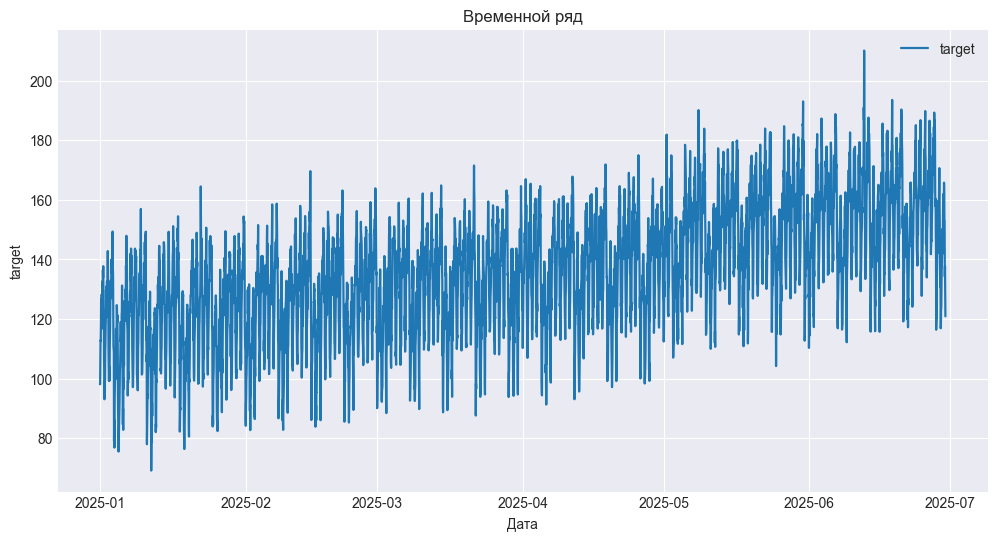

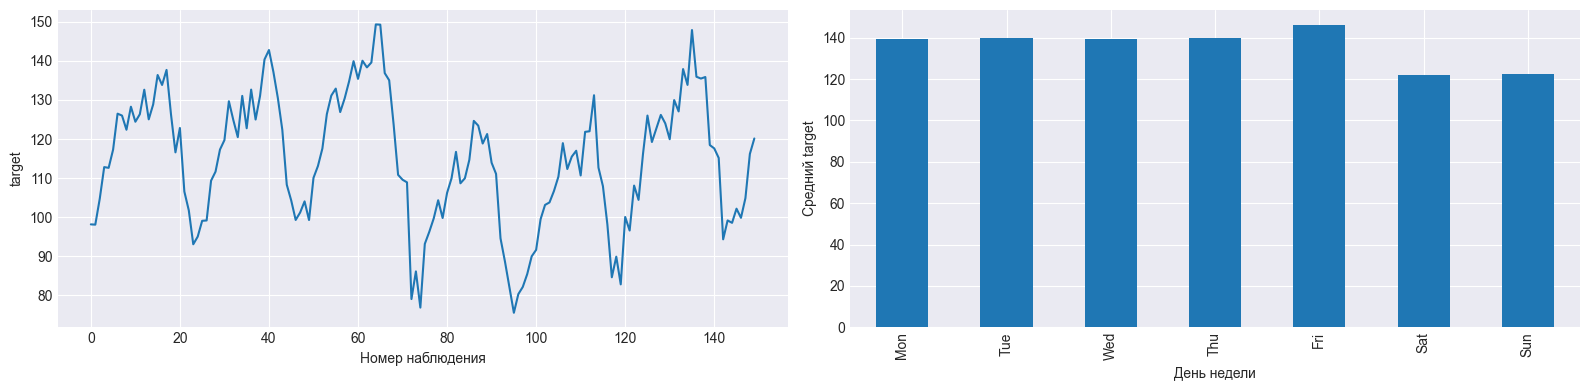

In [47]:
# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df["target"].iloc[:150].plot(ax=axes[0])
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("target")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний target")

plt.tight_layout()
plt.show()


## Анализ временного ряда

### 1. **Тренд**
На основном графике наблюдается слабовыраженный возрастающий тренд. Значения ряда колеблются в диапазоне от примерно 80 до 150, при этом общая тенденция показывает постепенный рост от начала к концу периода. Тренд не является строго линейным — периоды роста сменяются периодами относительной стабильности.

### 2. **Сезонность**
- **Недельная сезонность отсутствует** — различия между днями недели минимальны, что видно на втором подграфике. Это можно отнести к случайным колебаниям, а не к закономерной сезонности.
- **Присутствует сезонность с периодичностью около 20-30 наблюдений** — на графике прослеживаются регулярные подъемы и спады с интервалом примерно 20-30 записей(дневная цикличность). Амплитуда колебаний составляет около 70 единиц.

### 3. **Выбросы**
На первом подграфике видны отдельные резкие пики и спады:
- Это указывает на наличие выбросов или аномальных событий, требующих дополнительного анализа

### 4. **Нестационарность**
Ряд является **нестационарным** по следующим причинам:
- **Среднее значение непостоянно** — есть периоды подъемов и спадов
- **Дисперсия меняется во времени** — амплитуда колебаний в разные периоды различается
- **Наличие циклической компоненты** (периодичность 20-30 наблюдений) также указывает на нестационарность ряда

Корректный temporal split

train: 2025-01-01 → 2025-05-24 | 3456 строк
val:   2025-05-25 → 2025-06-11 | 432 строк
test:  2025-06-12 → 2025-06-29 | 432 строк


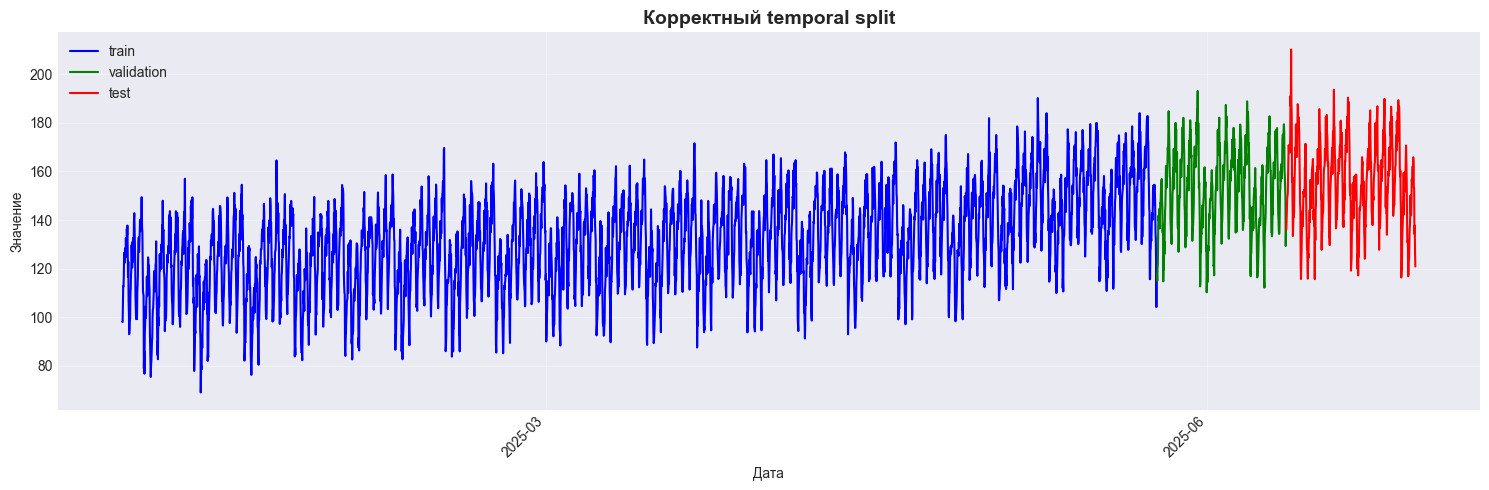

In [48]:
from dataclasses import dataclass
import math
from sklearn.model_selection import train_test_split

@dataclass
class SplitConfig:
    train_frac: float = 0.80
    val_frac: float = 0.10
    test_frac: float = 0.10

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

# Выполняем temporal split
train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

# Визуализация корректного temporal split
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train", color='blue', linewidth=1.5)
ax.plot(val_df["date"], val_df["target"], label="validation", color='green', linewidth=1.5)
ax.plot(test_df["date"], test_df["target"], label="test", color='red', linewidth=1.5)
ax.set_title("Корректный temporal split", fontsize=14, fontweight='bold')
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
ax.grid(True, alpha=0.3)

# Форматирование оси x
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Признаки для baseline-моделей

In [49]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

# Применяем функции к данным
features_df = add_calendar_features(df)
features_df = add_lag_features(features_df, target_col="target")

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,0.974928,-0.222521,0.5,0.866025,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,0.974928,-0.222521,0.5,0.866025,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,0.974928,-0.222521,0.5,0.866025,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,0.974928,-0.222521,0.5,0.866025,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,0.974928,-0.222521,0.5,0.866025,137.71,126.35,112.62,131.550000,4.907936


In [50]:
# Добавьте после создания features_df (ячейка "Признаки для baseline-моделей"):

# Создаем все необходимые признаки
def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()
    
    # Лаги
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    
    # Rolling statistics (сдвинутые на 1, чтобы избежать look-ahead)
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    
    return out

# Применяем
features_df = add_calendar_features(df)
features_df = add_lag_features(features_df, target_col="target")

# Удаляем строки с NaN (появились из-за shift и rolling)
features_df = features_df.dropna().reset_index(drop=True)

In [51]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7", 
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3444, 11) | y_train: (3444,)
X_val:   (431, 11) | y_val:   (431,)
X_test:  (431, 11) | y_test:  (431,)


In [52]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)        # transform для test

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины window_size
        y.append(series_2d[i + window_size, 0])         # Цель: следующее значение
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (3428, 28, 1) y_train: (3428,)
X_val  : (404, 28, 1) y_val  : (404,)
X_test : (404, 28, 1) y_test : (404,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6654752  -1.6690292  -1.3324178  -0.9206654  -0.93031186]
Цель (следующее значение): -0.98006743


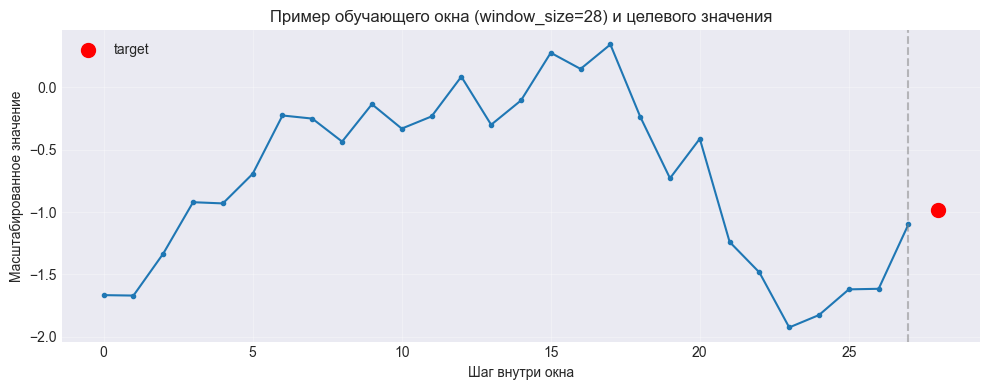

In [53]:
sample_idx = 0
print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель (следующее значение):", y_train[sample_idx])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o", markersize=3, linewidth=1.5)
ax.scatter([window_size], [y_train[sample_idx]], s=100, color='red', label="target", zorder=5)
ax.set_title(f"Пример обучающего окна (window_size={window_size}) и целевого значения", fontsize=12)
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Масштабированное значение")
ax.axvline(x=window_size-1, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("\n=== ПРОВЕРКА ФОРМЫ БАТЧА ===")
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

print("\n=== ИТОГОВАЯ ИНФОРМАЦИЯ ===")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")
print(f"Batch size: {batch_size}")
print(f"Window size: {window_size}")


=== ПРОВЕРКА ФОРМЫ БАТЧА ===
Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])

=== ИТОГОВАЯ ИНФОРМАЦИЯ ===
Train samples: 3428
Val samples: 404
Test samples: 404
Batch size: 64
Window size: 28


In [55]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out


In [56]:
# Параметры GRU
window_size = 28
batch_size = 64
hidden_size = 64
num_layers = 2
dropout = 0.2
learning_rate = 0.001
num_epochs = 100

In [57]:
# Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Инициализация
model = GRUModel(input_size=1, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)


In [58]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds, all_targets = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(outputs.detach().cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader)
    metrics = calculate_metrics(all_targets, all_preds)
    return avg_loss, metrics['mae'], metrics['rmse'], metrics['mape']

In [59]:
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader)
    metrics = calculate_metrics(all_targets, all_preds)
    return avg_loss, metrics['mae'], metrics['rmse'], metrics['mape'], np.array(all_preds), np.array(all_targets)


Эксперименты

Функции для метрик

In [60]:
def calculate_metrics(y_true, y_pred):
    """Расчет MAE, RMSE, MAPE"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

    return {'mae': mae, 'rmse': rmse, 'mape': mape}

Эксперимент B1: Naive (last value)

In [61]:
# B1: Naive (last value)
b1_val_pred = val_df['target'].shift(1).values
b1_val_true = val_df['target'].values

# Удаляем NaN синхронно
valid_mask = ~np.isnan(b1_val_pred)
b1_val_pred = b1_val_pred[valid_mask]
b1_val_true = b1_val_true[valid_mask]

# Вычисляем метрики
b1_val_metrics = calculate_metrics(b1_val_true, b1_val_pred)
print(f"Validation: MAE={b1_val_metrics['mae']:.4f}, RMSE={b1_val_metrics['rmse']:.4f}, MAPE={b1_val_metrics['mape']:.2f}%")



Validation: MAE=6.2126, RMSE=7.8752, MAPE=4.14%


Эксперимент B2: Moving Average

In [62]:
# B2: Moving Average
window_ma = 7
b2_val_pred = val_df['target'].shift(1).rolling(window=window_ma).mean().values
b2_val_true = val_df['target'].values

# Удаляем NaN синхронно
valid_mask = ~np.isnan(b2_val_pred)
b2_val_pred = b2_val_pred[valid_mask]
b2_val_true = b2_val_true[valid_mask]

# Метрики на validation
b2_val_metrics = calculate_metrics(b2_val_true, b2_val_pred)
print(f"Validation: MAE={b2_val_metrics['mae']:.4f}, RMSE={b2_val_metrics['rmse']:.4f}, MAPE={b2_val_metrics['mape']:.2f}%")



Validation: MAE=12.7148, RMSE=15.1004, MAPE=8.64%


Эксперимент B3: Ridge на признаках

In [63]:
# Убедитесь, что features_df создан со всеми признаками
print("Колонки в features_df:", features_df.columns.tolist())

# Признаки для baseline
feature_cols_b3 = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7', 
    'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

# Проверка наличия всех колонок
missing_cols = [col for col in feature_cols_b3 if col not in features_df.columns]
if missing_cols:
    print(f"ОШИБКА: отсутствуют колонки: {missing_cols}")
    # Создаем недостающие колонки
    for col in missing_cols:
        if col.startswith('lag_'):
            lag = int(col.split('_')[1])
            features_df[col] = features_df['target'].shift(lag)
        elif col.startswith('rolling_mean_'):
            window = int(col.split('_')[2])
            features_df[col] = features_df['target'].shift(1).rolling(window=window).mean()
        elif col.startswith('rolling_std_'):
            window = int(col.split('_')[2])
            features_df[col] = features_df['target'].shift(1).rolling(window=window).std()

# Удаляем NaN
features_df_clean = features_df.dropna().reset_index(drop=True)

# Разбиваем
train_feat, val_feat, test_feat = temporal_split(features_df_clean)

X_train_b3 = train_feat[feature_cols_b3]
y_train_b3 = train_feat['target'].values

X_val_b3 = val_feat[feature_cols_b3]
y_val_b3 = val_feat['target'].values

X_test_b3 = test_feat[feature_cols_b3]
y_test_b3 = test_feat['target'].values

# Масштабирование
scaler_b3 = StandardScaler()
X_train_b3_scaled = scaler_b3.fit_transform(X_train_b3)
X_val_b3_scaled = scaler_b3.transform(X_val_b3)
X_test_b3_scaled = scaler_b3.transform(X_test_b3)

# Обучение
ridge_model = Ridge(alpha=1.0, random_state=SEED)
ridge_model.fit(X_train_b3_scaled, y_train_b3)

# Предсказания
b3_val_pred = ridge_model.predict(X_val_b3_scaled)


# Метрики
b3_val_metrics = calculate_metrics(y_val_b3, b3_val_pred)
print(f"Validation: MAE={b3_val_metrics['mae']:.4f}, RMSE={b3_val_metrics['rmse']:.4f}, MAPE={b3_val_metrics['mape']:.2f}%")

Колонки в features_df: ['date', 'target', 'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
Validation: MAE=6.9866, RMSE=8.6070, MAPE=4.70%


Эксперимент R1: GRU

In [64]:

best_val_loss = float('inf')
best_model_state = None
best_epoch = 0
best_val_mae = None
best_val_rmse = None
best_val_mape = None
history = {'train_loss': [], 'train_mae': [], 'val_loss': [], 'val_mae': []}

print("\nНачало обучения GRU...")
for epoch in range(num_epochs):
    train_loss, train_mae_scaled, train_rmse_scaled, train_mape_scaled = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_mae_scaled, val_rmse_scaled, val_mape_scaled, val_preds_scaled, val_targets_scaled = validate(model, val_loader, criterion, device)

    # Конвертируем validation предсказания в исходный масштаб для метрик
    val_preds = scaler.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()
    val_targets = scaler.inverse_transform(val_targets_scaled.reshape(-1, 1)).flatten()
    val_metrics = calculate_metrics(val_targets, val_preds)
    val_mae, val_rmse, val_mape = val_metrics['mae'], val_metrics['rmse'], val_metrics['mape']

    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae_scaled)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    # Сохраняем лучшую модель по loss на validation (в масштабированном виде)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        best_epoch = epoch + 1
        best_val_mae = val_mae
        best_val_rmse = val_rmse
        best_val_mape = val_mape

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val MAE={val_mae:.4f}")

print(f"\nЛучшая модель: epoch {best_epoch}, Val MAE={best_val_mae:.4f}")

# Оценка на test
model.load_state_dict(best_model_state)
test_loss, test_mae_scaled, test_rmse_scaled, test_mape_scaled, test_preds_scaled, test_targets_scaled = validate(
    model, test_loader, criterion, device
)

# Конвертируем test предсказания в исходный масштаб
test_preds = scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()
test_targets = scaler.inverse_transform(test_targets_scaled.reshape(-1, 1)).flatten()

# Вычисляем метрики на исходных значениях
test_metrics = calculate_metrics(test_targets, test_preds)
print(f"\nTest: MAE={test_metrics['mae']:.4f}, RMSE={test_metrics['rmse']:.4f}, MAPE={test_metrics['mape']:.2f}%")

# Сохраняем метрики для таблицы
r1_val_metrics = {'mae': best_val_mae, 'rmse': best_val_rmse, 'mape': best_val_mape}
r1_test_metrics = {'mae': test_metrics['mae'], 'rmse': test_metrics['rmse'], 'mape': test_metrics['mape']}

# Сохранение модели
torch.save(best_model_state, 'artifacts/best_gru.pt')


Начало обучения GRU...
Epoch  10: Train Loss=0.1146, Val Loss=0.1250, Val MAE=5.5956
Epoch  20: Train Loss=0.1002, Val Loss=0.0925, Val MAE=4.7428
Epoch  30: Train Loss=0.0927, Val Loss=0.0840, Val MAE=4.5143
Epoch  40: Train Loss=0.0910, Val Loss=0.0829, Val MAE=4.4689
Epoch  50: Train Loss=0.0926, Val Loss=0.0829, Val MAE=4.4695
Epoch  60: Train Loss=0.0902, Val Loss=0.0829, Val MAE=4.4697
Epoch  70: Train Loss=0.0915, Val Loss=0.0829, Val MAE=4.4697
Epoch  80: Train Loss=0.0913, Val Loss=0.0829, Val MAE=4.4697
Epoch  90: Train Loss=0.0930, Val Loss=0.0829, Val MAE=4.4697
Epoch 100: Train Loss=0.0914, Val Loss=0.0829, Val MAE=4.4697

Лучшая модель: epoch 22, Val MAE=4.3527

Test: MAE=4.8459, RMSE=6.2114, MAPE=3.18%


In [65]:
# Сохранение конфига
config = {
    'model': 'GRU',
    'input_size': 1,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'dropout': dropout,
    'window_size': window_size,
    'batch_size': batch_size,
    'learning_rate': learning_rate,
    'num_epochs': num_epochs,
    'best_epoch': best_epoch,
    'seed': SEED,
    'scaler': 'StandardScaler (fit on train)'
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)

In [66]:
split_summary = f"Train: {train_df['date'].min()} - {train_df['date'].max()}, " \
                f"Val: {val_df['date'].min()} - {val_df['date'].max()}, " \
                f"Test: {test_df['date'].min()} - {test_df['date'].max()}"

results = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Naive (last value)',
        'features_summary': 'lag_1',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b1_val_metrics['mae'],
        'best_val_rmse': b1_val_metrics['rmse'],
        'best_val_mape': b1_val_metrics['mape'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Прогноз = последнее известное значение'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': 7,
        'horizon': 1,
        'model_summary': 'Moving Average',
        'features_summary': 'rolling_mean_7',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b2_val_metrics['mae'],
        'best_val_rmse': b2_val_metrics['rmse'],
        'best_val_mape': b2_val_metrics['mape'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': f'Скользящее среднее по окну {window_ma}'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge Regression',
        'features_summary': f'{len(feature_cols_b3)} features: лаги, rolling stats, календарные',
        'scaler': 'StandardScaler (fit on train)',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b3_val_metrics['mae'],
        'best_val_rmse': b3_val_metrics['rmse'],
        'best_val_mape': b3_val_metrics['mape'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'alpha=1.0'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': window_size,
        'horizon': 1,
        'model_summary': f'GRU (hidden_size={hidden_size}, layers={num_layers}, dropout={dropout})',
        'features_summary': 'Оконное представление ряда (window_size=28)',
        'scaler': 'StandardScaler (fit on train)',
        'optimizer': 'Adam',
        'lr': learning_rate,
        'epochs_trained': best_epoch,
        'best_val_mae': r1_val_metrics['mae'],
        'best_val_rmse': r1_val_metrics['rmse'],
        'best_val_mape': r1_val_metrics['mape'],
        'test_mae': r1_test_metrics['mae'],
        'test_rmse': r1_test_metrics['rmse'],
        'test_mape': r1_test_metrics['mape'],
        'notes': f'Лучшая модель на epoch {best_epoch}'
    }
]

runs_df = pd.DataFrame(results)
runs_df.to_csv('artifacts/runs.csv', index=False)
print("\n Результаты сохранены в artifacts/runs.csv")
display(runs_df)


 Результаты сохранены в artifacts/runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-05-24 23:00:...,NaN,1,Naive (last value),lag_1,None,None,NaN,NaN,6.212552,7.875221,4.139173,NaN,NaN,NaN,Прогноз = последнее известное значение
1,B2,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-05-24 23:00:...,7.0,1,Moving Average,rolling_mean_7,None,None,NaN,NaN,12.714800,15.100412,8.640371,NaN,NaN,NaN,Скользящее среднее по окну 7
2,B3,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-05-24 23:00:...,NaN,1,Ridge Regression,"11 features: лаги, rolling stats, календарные",StandardScaler (fit on train),None,NaN,NaN,6.986569,8.607023,4.702148,NaN,NaN,NaN,alpha=1.0
3,R1,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-05-24 23:00:...,28.0,1,"GRU (hidden_size=64, layers=2, dropout=0.2)",Оконное представление ряда (window_size=28),StandardScaler (fit on train),Adam,0.001,22.0,4.352735,5.610141,2.879728,4.845906,6.211414,3.176932,Лучшая модель на epoch 22


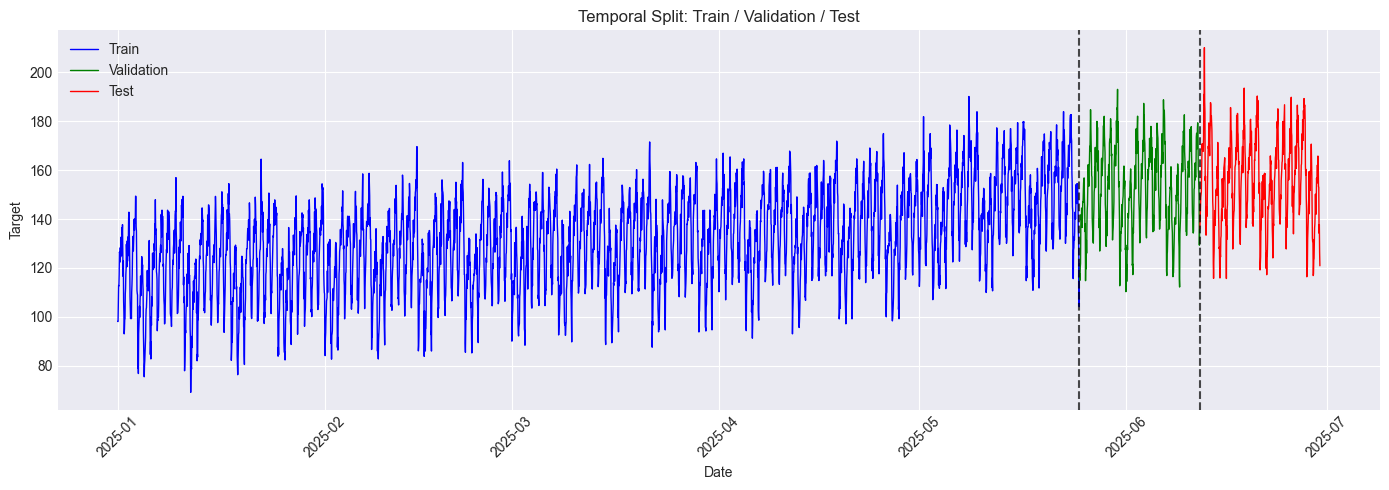

In [67]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df['date'], train_df['target'], label='Train', color='blue', linewidth=1)
ax.plot(val_df['date'], val_df['target'], label='Validation', color='green', linewidth=1)
ax.plot(test_df['date'], test_df['target'], label='Test', color='red', linewidth=1)
ax.axvline(x=train_df['date'].max(), color='black', linestyle='--', alpha=0.7)
ax.axvline(x=val_df['date'].max(), color='black', linestyle='--', alpha=0.7)
ax.set_title('Temporal Split: Train / Validation / Test')
ax.set_xlabel('Date')
ax.set_ylabel('Target')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()


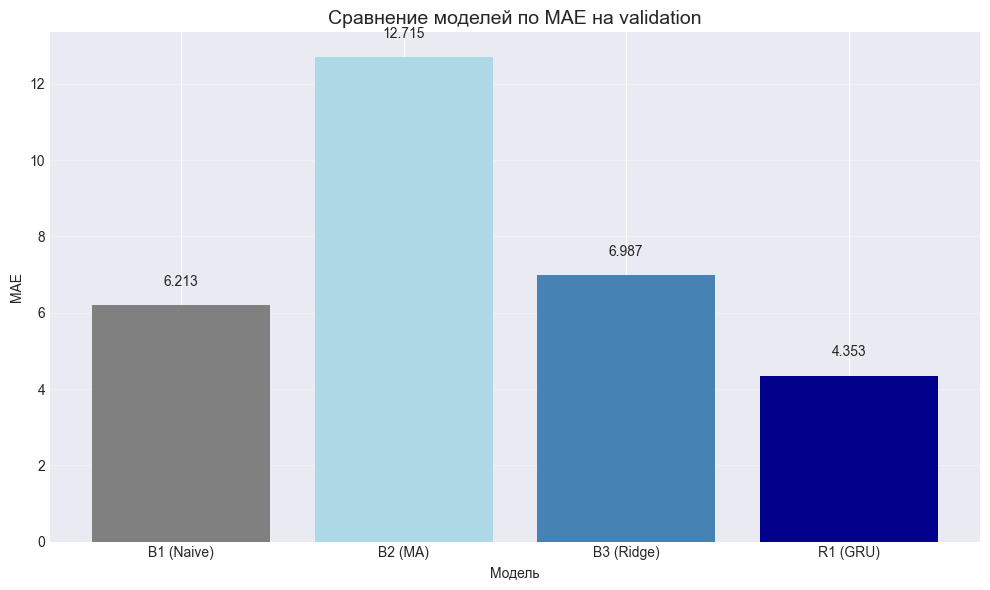

In [68]:
val_results = {
    'B1 (Naive)': b1_val_metrics['mae'],
    'B2 (MA)': b2_val_metrics['mae'],
    'B3 (Ridge)': b3_val_metrics['mae'],
    'R1 (GRU)': r1_val_metrics['mae']
}

fig, ax = plt.subplots(figsize=(10, 6))
models = list(val_results.keys())
mae_values = list(val_results.values())
bars = ax.bar(models, mae_values, color=['gray', 'lightblue', 'steelblue', 'darkblue'])
ax.set_title('Сравнение моделей по MAE на validation', fontsize=14)
ax.set_ylabel('MAE')
ax.set_xlabel('Модель')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mae_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

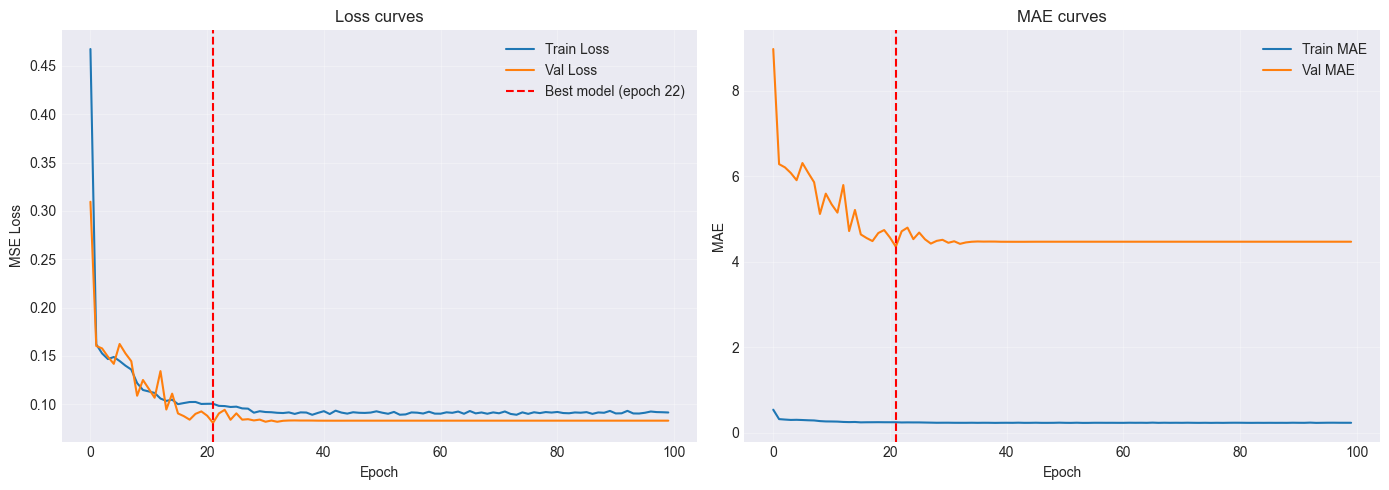

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=1.5)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=1.5)
axes[0].axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best model (epoch {best_epoch})')
axes[0].set_title('Loss curves', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_mae'], label='Train MAE', linewidth=1.5)
axes[1].plot(history['val_mae'], label='Val MAE', linewidth=1.5)
axes[1].axvline(x=best_epoch-1, color='red', linestyle='--')
axes[1].set_title('MAE curves', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Лучшая модель по MAE на validation: R1


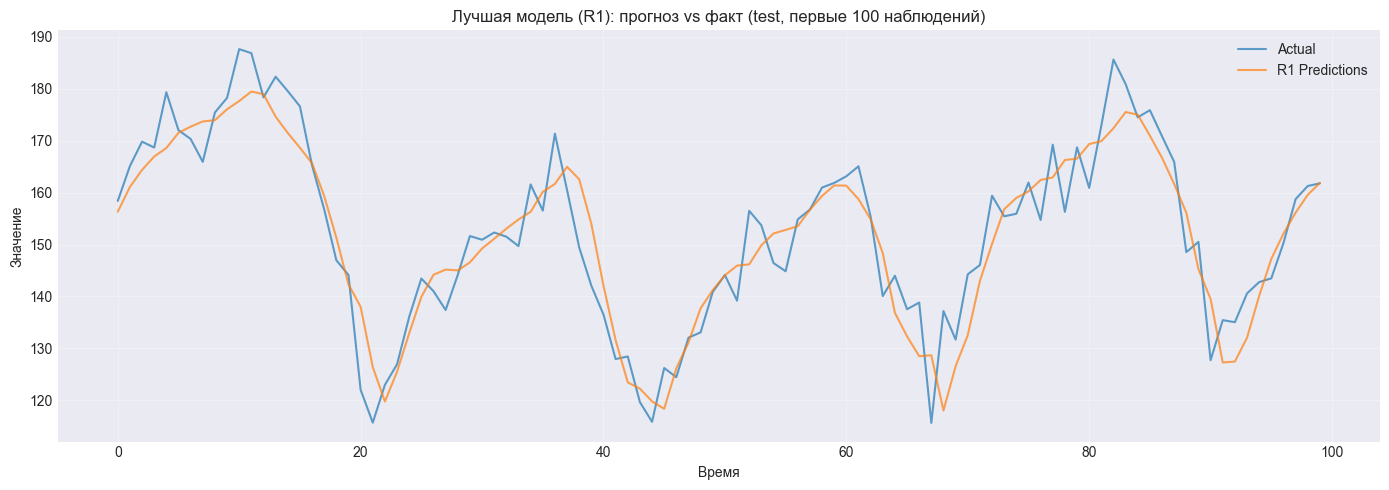

In [70]:
best_model_id = runs_df.loc[runs_df['best_val_mae'].idxmin(), 'experiment_id']
print(f"\nЛучшая модель по MAE на validation: {best_model_id}")


best_test_pred, best_test_true = test_preds, test_targets

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(best_test_true[:100], label='Actual', linewidth=1.5, alpha=0.7)
ax.plot(best_test_pred[:100], label=f'{best_model_id} Predictions', linewidth=1.5, alpha=0.7)
ax.set_title(f'Лучшая модель ({best_model_id}): прогноз vs факт (test, первые 100 наблюдений)', fontsize=12)
ax.set_xlabel('Время')
ax.set_ylabel('Значение')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()